# G0 — Do the global *off* and *unity* runs give the same results?

Complete for the two-day comparison; last update: 8 October 2026.

The full `G0` checker found exact equality in all three histories and both restarts. This notebook makes that result easier to read by showing Arctic and Antarctic totals and statistics from the final daily mean. 

In [2]:
from pathlib import Path
import os, sys, json, csv, html, subprocess
from IPython.display import display, HTML

repo = Path(os.environ.get("CICE_MODEL_REPO", "/g/data/gv90/da1339/src/CICE_dyntens")).expanduser().resolve()
runs   = Path(os.environ.get("CICE_TEST_RUNS", "/g/data/gv90/da1339/cice-dirs/runs")).expanduser().resolve()
output = repo / "validation_report/global/g0_summary"

# Final daily mean; the instantaneous stop is represented by the final restart.
history_name = "iceh.2000-09-02.nc"
off = runs / "dt_g0_off/history" / history_name
unity = runs / "dt_g0_unity/history" / history_name
latitude_cutoff = 0.0  # NH > 0 degrees, SH < 0 degrees; change only with a stated regional definition.
ice_threshold = 0.15 # Extent and selected-cell field statistics.
rows_per_chunk = 32

if not (repo / "cice.setup").is_file():
    raise FileNotFoundError("Set CICE_MODEL_REPO to your CICE_dyntens checkout")
for path in (off, unity):
    if not path.is_file():
        raise FileNotFoundError(path)
print("Off:", off)
print("Unity:", unity)


Off: /g/data/gv90/da1339/cice-dirs/runs/dt_g0_off/history/iceh.2000-09-02.nc
Unity: /g/data/gv90/da1339/cice-dirs/runs/dt_g0_unity/history/iceh.2000-09-02.nc


## Full comparison record

Use the `G0` workflow to check the entire output first. This notebook reads its result; it does not award a new PASS from matching regional averages. The supplied `G0` comparison passed, but the local evidence file must also show PASS before these tables are generated.


In [ ]:
evidence = repo / "validation_report/global/evidence/g0-short-validation.json"
if not evidence.is_file():
    raise FileNotFoundError("Run g0_global_workflow.py analyse --evidence validation_report/global/evidence first")
record = json.loads(evidence.read_text())
if record.get("status") != "PASS" or record.get("gate") != "G0-short":
    raise ValueError("The local full G0 comparison is not recorded as PASS")
print("Full G0 comparison:", record["status"])


## Read the final daily mean

This cell may take a little time to read and hash both files. It uses the notebook's Python environment in a separate process; that environment needs NumPy and netCDF4, but not GMT/PyGMT. If it fails, the error and process return code are shown here. The kernel can remain running.


In [ ]:
command = [sys.executable, "-m", "CICE_testing.validation.global_summary",
           "--off", str(off), "--unity", str(unity), "--output", str(output),
           "--latitude-cutoff", str(latitude_cutoff), "--ice-threshold", str(ice_threshold),
           "--rows", str(rows_per_chunk)]
result = subprocess.run(command, cwd=repo, capture_output=True, text=True)
print(result.stdout)
if result.returncode:
    print(result.stderr)
    raise RuntimeError(f"Summary process exited with code {result.returncode}; see its error above")
summary = json.loads((output / "g0-regional-summary.json").read_text())
print("Time and interval:", summary["time"])
print("Fields not summarised:", "; ".join(summary["skipped_fields"]))


## Circum-Arctic and circum-Antarctic totals

Here these names mean all ocean cells in the northern and southern hemispheres, respectively. Land and the equator are excluded. Using all hemispheric ocean cells includes the surrounding seasonal ice seas; a different latitude cutoff defines a different comparison.

Ice area = sum(cell area × ice concentration). Ice extent = sum(cell area where daily mean concentration is at least 15%). Ice volume = sum(cell area × `hi`), where `hi` is ice volume per grid-cell area. Mean ice-covered thickness = total volume / total ice area.

These quantities use the final **daily mean**, not an instantaneous stop-time state. The table should show zero unity-minus-off differences.


In [ ]:
def show_csv(path):
    with path.open(newline="") as stream:
        reader = csv.DictReader(stream)
        rows = list(reader)
        columns = reader.fieldnames or []
    def formatted(value):
        if value in (None, ""):
            return "—"
        try:
            return f"{float(value):.8g}"
        except ValueError:
            return value
    head = "".join(f"<th>{html.escape(c)}</th>" for c in columns)
    body = "".join("<tr>" + "".join(f"<td>{html.escape(formatted(row[c]))}</td>" for c in columns) + "</tr>" for row in rows)
    display(HTML(f"<table><thead><tr>{head}</tr></thead><tbody>{body}</tbody></table>"))
    print("CSV:", path)
    return rows

totals = show_csv(output / "g0-regional-totals.csv")


## Available strength and deformation fields

Means and standard deviations use ice-area weights (cell area × daily mean concentration), selecting cells with concentration at least the threshold. Minimum and maximum are over valid selected cells. The valid-ice-area fractions show whether masking reduced coverage.

The largest cell difference and unequal-cell counts supplement the regional statistics: equal means alone could hide differences that cancel. `hs` and `Tsfc` were not written in these runs; missing fields are listed above. Fields on velocity grids are not mixed with T-cell weights or silently interpolated. Units come from the actual history variables.


In [ ]:
fields = show_csv(output / "g0-regional-fields.csv")
print("Summary record:", output / "g0-regional-summary.json")


## Interpretation

For the completed G0 pair, every reported difference should be zero. The full exact-file comparison remains the evidence of equality; these tables present selected regional results.

The comparison shows that switching on the constant unity coefficient left this two-day global solution unchanged. The thermal restart variables also matched. It does not establish seasonal performance, an independent heat budget, WHACS loading or the behaviour of a changing FSD-based coefficient. Those questions remain for G1/G2.


# G0 passed
The next step is to inspect the evolving FSD in the completed G0 runs before choosing the settings for a diagnostic-only G1 run.

In [ ]:
repo       = Path("/g/data/gv90/da1339/src/CICE_dyntens")
run        = Path("/g/data/gv90/da1339/cice-dirs/runs/dt_g0_off")
report_dir = repo / "validation_report/global/G1/evidence"
report_dir.mkdir(parents = True, exist_ok = True)
report   = report_dir / "g1-fsd-inspection.txt"
script   = repo / "CICE_testing/scripts/diagnose_restart_fsd.py"
history  = run / "history/iceh.2000-09-01.nc"
restarts = [run / "input_restart/iced.2000-09-01-00000.nc",
            run / "restart/iced.2000-09-02-00000.nc",
            run / "restart/iced.2000-09-03-00000.nc"]

for path in [script, history, *restarts]:
    if not path.is_file():
        raise FileNotFoundError(path)

command = [sys.executable, "-u", str(script), "--grid-history", str(history), *map(str, restarts)]

with report.open("w", encoding="utf-8") as log:
    with subprocess.Popen(command, cwd = repo, stdout = subprocess.PIPE, stderr = subprocess.STDOUT, text = True, bufsize = 1) as process:
        for line in process.stdout:
            print(line, end = "", flush = True)
            log.write(line)
            log.flush()
        returncode = process.wait()

if returncode:
    raise subprocess.CalledProcessError(returncode, command)

print(f"\nFSD inspection completed. Report saved to:\n{report}")

# FSD inspection

No occupied ocean categories were classified as having invalid bins or a zero FSD sum in any of the three restarts. However, departures from a sum of one are widespread, particularly in Antarctica.

Here is the Antarctic ice area associated with categories exceeding each sum-error threshold:
| Absolute sum error |	1 Sep: input	| 2 Sep	 | 3 Sep |
|--------------------|----------------- | -------| -------|
| $>10^{-6}$	     | 34.14%	        | 35.87% | 34.64% |
| $>10^{-4}$	      | 3.28%	        | 3.73%	 | 3.86% |
| $>10^{-3} — 0.1$% | 0.277%	        | 0.5%   | 0.642% |
| $>10^{-2} — 1$%	  |negligible	    | 0.0234%| 0.00305% |

These percentages describe affected category ice area (`aicen`), not the magnitude of an ice-area deficit. The largest departures occur in tiny categories, but not exclusively. On 2 September, one category with `aicen`$=0.737$ has an FSD sum of approximately $1.030$. It therefore should probably not be outright dismissed as a negligible ice or round-off error.

There are two different comparisons to keep separate:
|Comparison | What it answers |
|-----------|-----------------|
|unity − off: aicen, FSD bins and physical fields| Did enabling $g=1$ change the model? `G0` already found exact equality.|
|Normalised diagnostic − raw diagnostic| How much do inherited FSD sum departures affect calculated $g$?|

I'll include `hi`, velocity, strength, divergence and shear. I'll use restarts for category FSD and aicen. History `afsdn` has units of $1/m$, so it cannot be treated as the restart’s integrated bin fractions.

## configuration and calculation

The diameter threshold and minimum $g$ below match the current source defaults. I'll check them against the settings intended for `G1`. The raw calculation deliberately retains sum departures; it is an exploratory calculation, not a successful call to the strict production mapper.

In [3]:
import re
import numpy as np
import pandas as pd
from netCDF4 import Dataset
repo = Path("/g/data/gv90/da1339/src/CICE_dyntens")
runs = Path("/g/data/gv90/da1339/cice-dirs/runs")
sys.path.insert(0, str(repo))
from CICE_testing.validation.fsd import read_grid, read_longitude

out = repo / "validation_report/global/G1/spatial"
out.mkdir(parents = True, exist_ok = True)
THRESHOLD_M   = 300.0
GMIN          = 0.2
OCCUPIED_MIN  = 1e-12
MAP_ERROR_MIN = 1e-4

grid_file           = runs / "dt_g0_off/history/iceh.2000-09-01.nc"
mask, lat, area_km2 = read_grid(grid_file)
lon                 = read_longitude(grid_file, mask)

# Read the 12-bin radius bounds from this checkout rather than inventing bins.
source = (repo / "icepack/columnphysics/icepack_fsd.F90").read_text()
match  = re.search(r"else\s*if\s*\(nfsd\.eq\.12\).*?lims\s*=\s*\(/(.*?)/\)", source, flags = re.S | re.I)
if match is None:
    raise ValueError("Cannot find the 12-bin FSD bounds in ICEPACK.")

bounds = np.array([float(v.replace("D", "e").replace("d", "e")) for v in match.group(1).replace("&", "").split(",") if v.strip()])
assert len(bounds) == 13
diameters = bounds[:-1] + bounds[1:]  # 2 × radius-bin midpoint
large_bins = diameters > THRESHOLD_M

print("Diameter-bin centres (m):", diameters)
print("Large-bin selection:", large_bins)
print("These bounds must match the executable used for the runs.")

Diameter-bin centres (m): [   5.37680847   19.59689457   43.3442547    81.4698822   140.2813541
  227.3876105   351.154222    519.673026    739.240333   1012.480284
 1336.418272   1700.953881  ]
Large-bin selection: [False False False False False False  True  True  True  True  True  True]
These bounds must match the executable used for the runs.


In [4]:
def decoded(variable, key):
    return np.ma.asarray(variable[key], dtype=float).filled(np.nan)

def restart_fields(path):
    """Read category FSD in row chunks; retain only derived 2-D maps."""
    shape = mask.shape
    result = {name: np.full(shape, np.nan) for name in ("aice", "sum_error", "weighted_sum_error", "g_raw", "g_normalised", "delta_g")}
    with Dataset(path) as ds:
        bins = sorted(n for n in ds.variables if re.fullmatch(r"fsd\d{3}", n))
        if len(bins) != 12:
            raise ValueError(f"{path}: expected 12 restart FSD bins.")
        if ds["aicen"].dimensions != ("ncat", "nj", "ni"):
            raise ValueError("Unexpected restart aicen dimensions.")
        if ds["aicen"].shape[1:] != shape:
            raise ValueError("Restart/history grids differ.")
        for j0 in range(0, shape[0], 32):
            sl  = slice(j0, min(j0 + 32, shape[0]))
            a   = decoded(ds["aicen"], (slice(None), sl, slice(None)))
            f   = np.stack([decoded(ds[n], (slice(None), sl, slice(None))) for n in bins])  # bin, category, row, column
            wet = mask[sl] == 1
            occupied = a > OCCUPIED_MIN
            if np.any(wet[None] & (~np.isfinite(a) | (a < 0))):
                raise ValueError(f"Invalid ocean category area in {path}.")
            sums           = f.sum(axis=0)
            valid_category = (np.all(np.isfinite(f) & (f >= 0), axis=0) & (sums > 0))
            valid          = wet & occupied.any(axis=0) & np.all(~occupied | valid_category, axis = 0)
            # Ignore unoccupied categories; never modify prognostic FSD.
            weights = np.where(occupied, a, 0.0)
            total   = weights.sum(axis=0)
            tail    = np.where(occupied, f[large_bins].sum(axis=0), 0.0)
            with np.errstate(divide="ignore", invalid="ignore"):
                raw_fraction   = (weights * tail).sum(axis = 0) / total
                norm_tail      = np.divide(tail, sums, out = np.zeros_like(tail), where = occupied & valid_category)
                norm_fraction  = (weights * norm_tail).sum(axis=0) / total
                weighted_error = (weights * np.where(occupied, np.abs(sums - 1), 0)).sum(axis=0) / total
            raw        = GMIN + (1 - GMIN) * raw_fraction
            normalised = GMIN + (1 - GMIN) * norm_fraction
            values     = {"aice": total,
                          "sum_error": np.max(np.where(occupied, np.abs(sums - 1), 0), axis=0),
                          "weighted_sum_error": weighted_error,
                          "g_raw": raw,
                          "g_normalised": normalised,
                          "delta_g": normalised - raw}
            for name, value in values.items():
                result[name][sl] = np.where(valid, value, np.nan)
    return result

In [5]:
snapshots = {}
for label in ("off", "unity"):
    root = runs / f"dt_g0_{label}"
    files = [root / "input_restart/iced.2000-09-01-00000.nc",
             root / "restart/iced.2000-09-02-00000.nc",
             root / "restart/iced.2000-09-03-00000.nc"]
    for day, path in enumerate(files):
        snapshots[label, day] = restart_fields(path)
        print("Read:", path.name, label)

Read: iced.2000-09-01-00000.nc off
Read: iced.2000-09-02-00000.nc off
Read: iced.2000-09-03-00000.nc off
Read: iced.2000-09-01-00000.nc unity
Read: iced.2000-09-02-00000.nc unity
Read: iced.2000-09-03-00000.nc unity


## choose cells and record their evolution

This selects two cells per hemisphere: the largest sum departure and the largest ice-area-weighted diagnostic effect, across all three snapshots. The latter avoids selecting only nearly empty categories.

In [6]:
selected = []
for hemisphere, domain in (("SH", (mask == 1) & (lat < 0)), ("NH", (mask == 1) & (lat >= 0))):
    scores = {"largest sum departure"         : np.max(np.stack([np.nan_to_num(snapshots["off", d]["sum_error"],
                                                                               nan = -np.inf) for d in range(3)]), axis = 0),
              "largest area-weighted g effect": np.max(np.stack([np.nan_to_num(area_km2 * snapshots["off", d]["aice"] * np.abs(snapshots["off", d]["delta_g"]),
                                                                               nan = -np.inf) for d in range(3)]), axis = 0)}
    for reason, score in scores.items():
        score = np.where(domain, score, -np.inf)
        if not np.isfinite(score).any():
            continue
        j, i = np.unravel_index(np.argmax(score), score.shape)
        if (j, i) not in [(r["j"], r["i"]) for r in selected]:
            selected.append(dict(cell      = f"{hemisphere}_{len(selected)+1}",
                                 reason    = reason, j = j, i = i,
                                 latitude  = lat[j, i],
                                 longitude = lon[j, i]))

cells = pd.DataFrame(selected)
display(cells.assign(j_1based = cells.j + 1, i_1based = cells.i + 1))

,cell,reason,j,i,latitude,longitude,j_1based,i_1based
0,SH_1,largest sum departure,65,686,-74.213093,-108.375000,66,687
1,SH_2,largest area-weighted g effect,134,1257,-66.926790,34.375000,135,1258
2,NH_3,largest sum departure,894,896,68.852515,-56.769095,895,897
3,NH_4,largest area-weighted g effect,992,1141,80.160409,13.155167,993,1142


In [7]:
records = []
for cell in selected:
    j, i = cell["j"], cell["i"]
    for label in ("off", "unity"):
        for day in range(3):
            fields = snapshots[label, day]
            records.append({"cell": cell["cell"],
                            "run": label,
                            "day": day,
                            "date": f"2000-09-{day+1:02d}",
                            **{name: values[j, i] for name, values in fields.items()}})

series = pd.DataFrame(records)
cells.to_csv(out / "selected-cells.csv", index=False)
series.to_csv(out / "restart-cell-series.csv", index=False)
display(series)

,cell,run,day,date,aice,sum_error,weighted_sum_error,g_raw,g_normalised,delta_g
0,SH_1,off,0,2000-09-01,0.965176,1.479137e-05,1.088503e-06,0.938289,0.938290,7.975360e-07
1,SH_1,off,1,2000-09-02,0.964929,3.556548e-05,7.221124e-07,0.938239,0.938240,5.293083e-07
2,SH_1,off,2,2000-09-03,0.964707,7.195065e-02,5.713794e-07,0.938239,0.938240,3.675259e-07
3,SH_1,unity,0,2000-09-01,0.965176,1.479137e-05,1.088503e-06,0.938289,0.938290,7.975360e-07
4,SH_1,unity,1,2000-09-02,0.964929,3.556548e-05,7.221124e-07,0.938239,0.938240,5.293083e-07
5,SH_1,unity,2,2000-09-03,0.964707,7.195065e-02,5.713794e-07,0.938239,0.938240,3.675259e-07
6,SH_2,off,0,2000-09-01,0.976693,2.338365e-07,1.502489e-07,0.957497,0.957497,-1.148044e-07
7,SH_2,off,1,2000-09-02,0.979375,1.637554e-02,1.615965e-02,0.836619,0.847077,1.045750e-02
8,SH_2,off,2,2000-09-03,0.982500,9.139273e-04,8.356750e-04,0.544336,0.544626,2.897128e-04
9,SH_2,unity,0,2000-09-01,0.976693,2.338365e-07,1.502489e-07,0.957497,0.957497,-1.148044e-07


In [8]:
# Descriptive map comparisons; the G0 validator remains the equality test.
comparison = []
for day in range(3):
    for name in snapshots["off", day]:
        a = snapshots["off", day][name]
        b = snapshots["unity", day][name]
        valid = np.isfinite(a) & np.isfinite(b)
        comparison.append({"day": day,
                           "field": name,
                           "validity_masks_equal": np.array_equal(np.isfinite(a), np.isfinite(b)),
                           "max_abs_unity_minus_off": np.max(np.abs(b[valid] - a[valid])) if valid.any() else np.nan})

comparison = pd.DataFrame(comparison)
comparison.to_csv(out / "derived-map-comparison.csv", index=False)
display(comparison)

,day,field,validity_masks_equal,max_abs_unity_minus_off
0,0,aice,True,0.0
1,0,sum_error,True,0.0
2,0,weighted_sum_error,True,0.0
3,0,g_raw,True,0.0
4,0,g_normalised,True,0.0
5,0,delta_g,True,0.0
6,1,aice,True,0.0
7,1,sum_error,True,0.0
8,1,weighted_sum_error,True,0.0
9,1,g_raw,True,0.0


## maps and cell time series

This plots cell-centre symbols without remapping. Maps use *off* because the `G0` physical outputs matched; the time series show both runs, with unity drawn as circles so coincident results remain visible.

In [9]:
from CICE_testing.plotting.maps import plot_scalar_map

regions = {"SH": [-180, 180, -90, -50], 
           "NH": [-180, 180, 50, 90]}

# Fixed diagnostic-difference scale across both hemispheres and all dates.
g_limit = max(1e-8, *[float(np.max(np.abs(v[np.isfinite(v)]))) for d in range(3) for v in [snapshots["off", d]["delta_g"]] if np.isfinite(v).any()])

def map_options(day, hemisphere, field):
    values = snapshots["off", day][field].copy()
    if field == "sum_error":
        values[values < MAP_ERROR_MIN] = np.nan
        with np.errstate(divide="ignore", invalid="ignore"):
            values = np.log10(values)
        limits = [float(np.log10(MAP_ERROR_MIN)), 0]
        cmap, label = "cmocean/amp", "log10 absolute FSD sum error"
    elif field == "delta_g":
        limits = [-g_limit, g_limit]
        cmap, label = "cmocean/balance", "Normalised minus raw diagnostic g"
    else:
        raise ValueError(field)
    return dict(values      = values,
                longitude   = lon,
                latitude    = lat,
                ocean_mask  = mask,
                region      = regions[hemisphere],
                limits      = limits,
                cmap        = cmap,
                title       = f"{hemisphere}: {field}, 2000-09-{day+1:02d}",
                color_label = label,
                markers     = selected,
                output_stem = out / f"{hemisphere}_{field}_day{day}")

In [12]:
for day in range(3):
    for hemisphere in regions:
        for field in ("sum_error", "delta_g"):
            print(f"Day {day}: {hemisphere}, {field}", flush=True)
            fig = maps.plot_scalar_map(**map_options(day, hemisphere, field), show = False)
            del fig
print(f"Figures saved to: {out}")

Day 0: SH, sum_error
Day 0: SH, delta_g
Day 0: NH, sum_error
Day 0: NH, delta_g
Day 1: SH, sum_error
Day 1: SH, delta_g
Day 1: NH, sum_error
Day 1: NH, delta_g
Day 2: SH, sum_error
Day 2: SH, delta_g
Day 2: NH, sum_error
Day 2: NH, delta_g
Figures saved to: /g/data/gv90/da1339/src/CICE_dyntens/validation_report/global/G1/spatial


1: Figure and basemap
Cell SH_1: blue
  off line
  unity circles
Cell SH_2: red
  off line
  unity circles
Cell NH_3: forestgreen
  off line
  unity circles
Cell NH_4: darkorange
  off line
  unity circles
3b: legend
3c: legend completed
4: save PNG
5: show


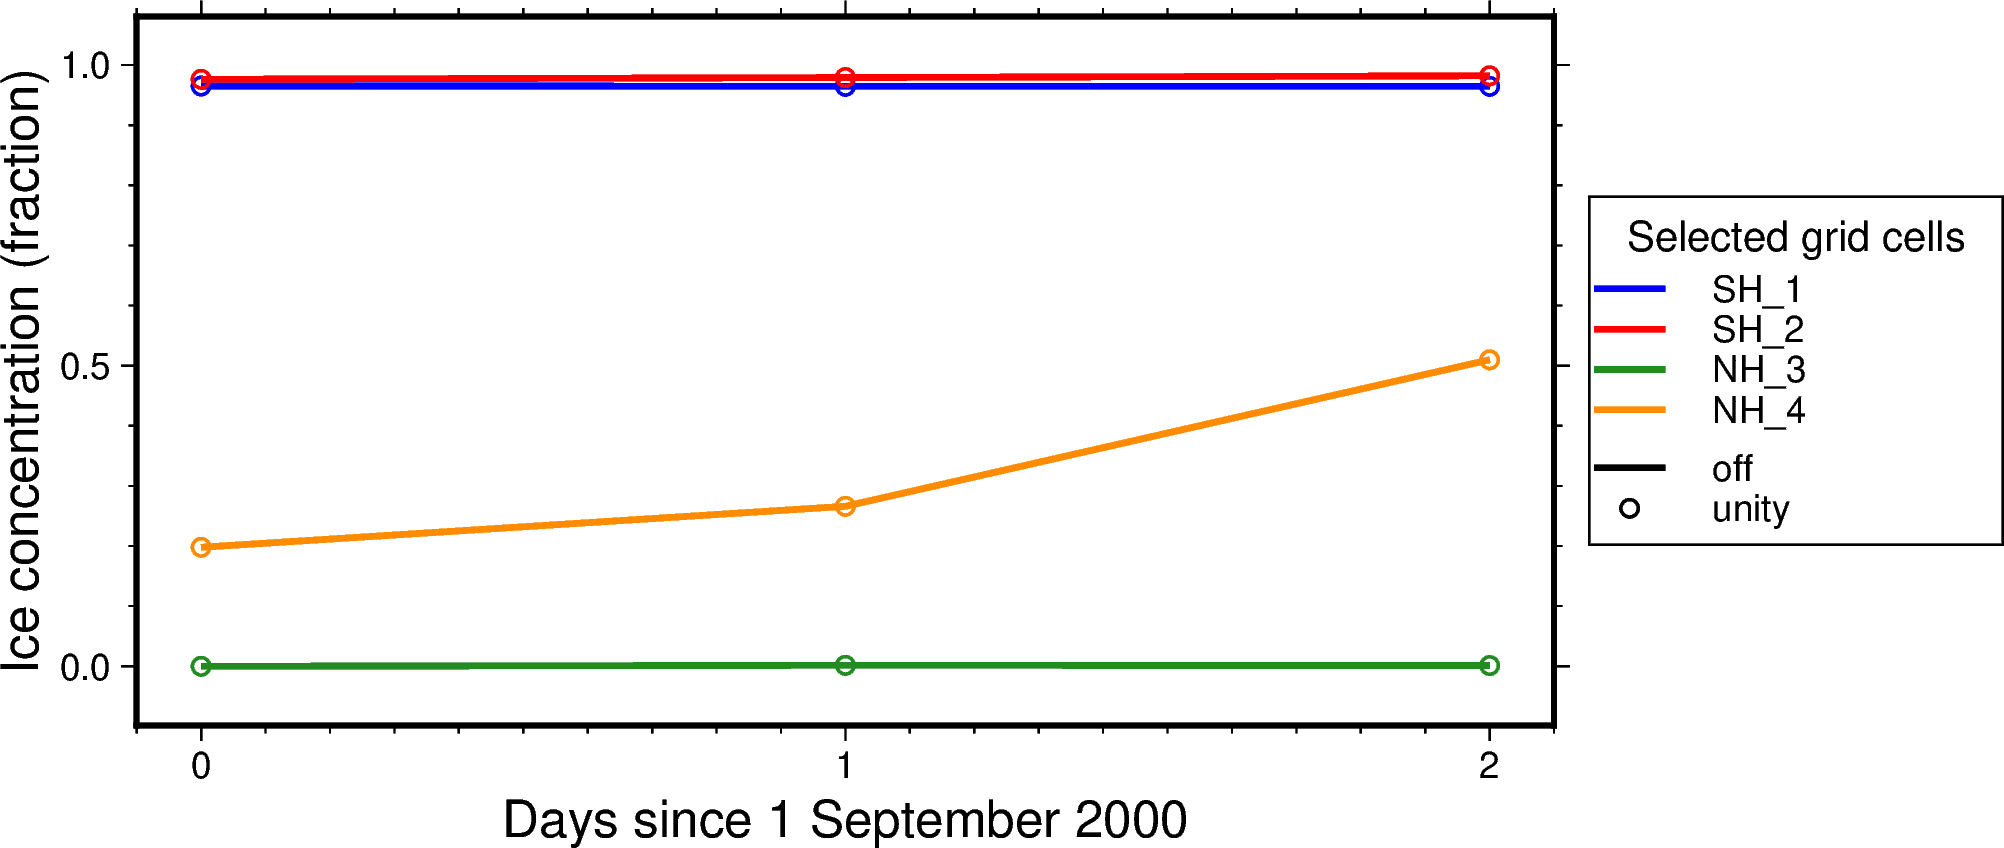

Completed


In [16]:
import numpy as np
import pygmt

field = "aice"
colours = [
    "blue", "red", "forestgreen", "darkorange",
    "purple", "brown", "magenta", "black",
]

# Prepare every table before calling GMT.
prepared = []

for cell in selected:
    cell_id = cell["cell"]
    subset = series[series.cell == cell_id]

    tables = {}
    for run in ("off", "unity"):
        rows = subset[subset.run == run].sort_values("day")
        table = rows[["day", field]].to_numpy(dtype=np.float64)
        tables[run] = np.ascontiguousarray(
            table[np.isfinite(table).all(axis=1)]
        )

    if any(table.shape[0] for table in tables.values()):
        prepared.append((cell_id, tables))
    else:
        print(f"Skipping {cell_id}: no finite {field} values", flush=True)

if not prepared:
    raise ValueError(f"No finite {field} values for selected cells")

finite = np.concatenate([
    table[:, 1]
    for _, tables in prepared
    for table in tables.values()
    if table.shape[0]
])

lo, hi = finite.min(), finite.max()
pad = max((hi - lo) * 0.1, abs(lo) * 0.01, 1e-8)

print("1: Figure and basemap", flush=True)
fig = pygmt.Figure()
fig.basemap(
    region=[-0.1, 2.1, float(lo - pad), float(hi + pad)],
    projection="X12c/6c",
    frame=[
        "xa1f+lDays since 1 September 2000",
        "yaf+lIce concentration (fraction)",
        "WSen",
    ],
)

for index, (cell_id, tables) in enumerate(prepared):
    colour = colours[index % len(colours)]
    print(f"Cell {cell_id}: {colour}", flush=True)

    if tables["off"].shape[0]:
        print("  off line", flush=True)
        fig.plot(data=tables["off"], pen=f"1.5p,{colour}")

    if tables["unity"].shape[0]:
        print("  unity circles", flush=True)
        fig.plot(
            data=tables["unity"],
            style="c0.15c",
            pen=f"0.7p,{colour}",
        )

import io

legend_lines = [
    "H 10p Helvetica Selected grid cells",
    "G 0.08c",
]

for index, (cell_id, _) in enumerate(prepared):
    colour = colours[index % len(colours)]
    legend_lines.append(
        f"S 0.2c - 0.6c - 1.5p,{colour} 0.9c {cell_id}"
    )

legend_lines.extend([
    "G 0.15c",
    "S 0.2c - 0.6c - 1.5p,black 0.9c off",
    "S 0.2c c 0.15c - 0.7p,black 0.9c unity",
])

print("3b: legend", flush=True)
fig.legend(
    spec=io.StringIO("\n".join(legend_lines) + "\n"),
    position="JMR+jML+o0.3c/0c+w3.5c",
    box="+gwhite+p0.5p",
)
print("3c: legend completed", flush=True)

print("4: save PNG", flush=True)
fig.savefig(Path(out / f"timeseries_{field}_selected-grid-cells.png"), dpi=180)

print("5: show", flush=True)
fig.show()

print("Completed", flush=True)